
---

## **Problem Statement**

**Title:**
Multi-Agent Task Orchestration using LangGraph with a Supervisor-Agent Architecture

---

## **Problem Description:**

This notebook demonstrates how to create a **multi-agent reasoning system** using **LangGraph** and **LangGraph Supervisor**, where a central **Supervisor Agent** delegates tasks to two specialized agents:

* A **Math Expert Agent** for performing arithmetic computations using built-in tools
* A **Research Expert Agent** for answering factual or web-based questions using DuckDuckGo search

The system leverages **agent routing**, **tool-calling**, and **role-specific prompting**, all orchestrated under a **LangGraph workflow**, making it modular, scalable, and explainable.

---

## **Architecture Overview**

```
                           ┌───────────────────────┐
                           │   Supervisor Agent     │
                           │  (Decision Controller) │
                           └────────────┬────────────┘
                                        │
          ┌─────────────────────────────┴────────────────────────────┐
          │                                                          │
┌──────────────────────────┐                           ┌────────────────────────────┐
│     Research Agent       │                           │      Math Agent            │
│ Uses: DuckDuckGo Search  │                           │ Uses: Add and Multiply     │
│ Prompt: "No math work"   │                           │ Prompt: "Only do math"     │
└──────────────────────────┘                           └────────────────────────────┘
```

---

## **Input**

| Field      | Description                                                                            |
| ---------- | -------------------------------------------------------------------------------------- |
| `messages` | A list of messages, typically with user role and a query in natural language. Example: |

```json
[
  {"role": "user", "content": "What is quantum computing?"}
]
```

---

## **Agent Role Descriptions**

| Agent                | Purpose                                     | Tool(s)               | Instructions                     |
| -------------------- | ------------------------------------------- | --------------------- | -------------------------------- |
| **Supervisor Agent** | Directs the task to the correct sub-agent   | None                  | Delegates based on query type    |
| **Math Agent**       | Handles all mathematical operations         | `add()`, `multiply()` | Must use one math tool at a time |
| **Research Agent**   | Handles fact-based or current event queries | `search_duckduckgo()` | Must not perform any math        |

---

## **Output**

| Output Type           | Example                                                                                 |
| --------------------- | --------------------------------------------------------------------------------------- |
| Final Response        | `"Quantum computing is a field of computing that uses quantum-mechanical phenomena..."` |
| Execution Path        | Captured via LangGraph trace or observable using LangSmith                              |
| Multiple Responses    | Available if sub-agents generate multi-turn output                                      |
| Pretty Printed Output | Done using `.pretty_print()` on result messages                                         |

---

## **Execution Workflow Summary**

1. **Define Tools**

   * `add()` and `multiply()` for math
   * `search_duckduckgo()` for search

2. **Create Agents**

   * `math_agent = create_react_agent(...)`
   * `research_agent = create_react_agent(...)`

3. **Create Supervisor**

   * Uses both agents and a meta-prompt to decide routing

4. **Compile Graph**

   * `app = workflow.compile()`

5. **Invoke Workflow**

   * Example 1: `quantum computing` → Research Agent
   * Example 2: `"multiply today's temperature by 2"` → Mixed

6. **View Results**

   * Use `result["messages"]` and `m.pretty_print()` for formatted outputs

---

## **Example Queries and Expected Flow**

| User Query                                                       | Routed To      | Why                              |
| ---------------------------------------------------------------- | -------------- | -------------------------------- |
| "What is quantum computing?"                                     | Research Agent | Requires factual lookup          |
| "Add 23 and 45"                                                  | Math Agent     | Pure arithmetic                  |
| "What is the weather in Delhi today? Multiply it by 2 and add 5" | Both Agents    | Requires chaining: Search → Math |

---

In [ ]:
%pip install -U "langchain-core>=0.3.72,<1.0.0" "langchain>=0.3.27,<0.4.0" "langchain-community>=0.3.17,<0.4.0" "langchain-openai>=0.2.14,<0.3.0" langgraph langgraph-supervisor duckduckgo-search -q

In [1]:
import langchain_core, langgraph, langchain_openai, langchain_community, pkgutil
print("langchain-core:", getattr(langchain_core, "__version__", "?"))
print("langgraph:", getattr(langgraph, "__version__", "?"))
print("langchain-openai:", getattr(langchain_openai, "__version__", "?"))
print("langchain-community:", getattr(langchain_community, "__version__", "?"))
import importlib.util, sys
print("has langchain_core.beta:", importlib.util.find_spec("langchain_core.beta") is not None)

/Users/ingledarshan/.local/share/virtualenvs/AH-KbrtVpZi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


langchain-core: 1.2.23
langgraph: ?
langchain-openai: ?
langchain-community: 0.4.1
has langchain_core.beta: False


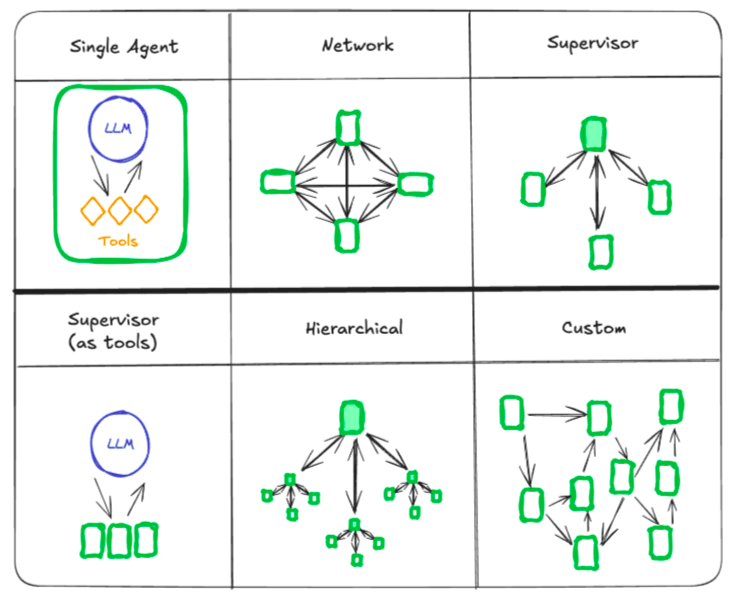

The diagram shows **different multi-agent architectures used in LLM systems**. Each pattern describes how agents communicate, coordinate, and divide tasks. Below is a clear explanation of each architecture with a real-world use case.

---

# 1. Single Agent

This is the simplest architecture. One LLM acts as the main agent and can call different tools when needed. The agent decides when to use a tool, processes the tool output, and produces the final response.

The workflow is straightforward:
User request → LLM agent → optional tool calls → final response.

This pattern is easy to implement and works well when the problem does not require multiple specialized agents.

Real-time use case:
A customer support chatbot for an e-commerce website. The agent can call tools like order lookup, product database search, or refund APIs to answer customer questions.

---

# 2. Network (Peer-to-Peer Agents)

In this architecture, multiple agents communicate with each other as peers. There is no central controller. Each agent can interact with other agents and collaborate to solve a problem.

Agents share information and collectively reach a solution. The system behaves like a distributed network where knowledge and responsibilities are spread across agents.

Real-time use case:
A collaborative research assistant system where different agents specialize in tasks such as web search, document summarization, citation extraction, and report writing. Each agent communicates with others to produce a research report.

---

# 3. Supervisor

In this design, one agent acts as a **supervisor or coordinator**. The supervisor receives the user request, decides which specialized agent should handle the task, and coordinates the workflow.

The supervisor controls task delegation and collects results from worker agents before returning the final answer.

Real-time use case:
A financial analysis system where a supervisor agent assigns tasks to different agents such as market data retrieval, risk analysis, and portfolio optimization before combining the results into a final investment report.

---

# 4. Supervisor (Agents as Tools)

In this pattern, the main LLM treats other agents as **tools**. Instead of directly coordinating multiple agents as a network, the main agent invokes specialized agents when needed, similar to calling APIs.

The main agent still controls the process but delegates specific tasks to specialized agents.

Real-time use case:
A travel planning assistant where the main agent calls specialized agents like flight search, hotel recommendation, and weather forecasting to build a complete travel itinerary.

---

# 5. Hierarchical

This architecture organizes agents in a hierarchy with multiple layers. A top-level agent delegates tasks to middle-level agents, which may further delegate work to lower-level agents.

Each layer focuses on a specific level of abstraction, allowing complex tasks to be broken into smaller manageable tasks.

Real-time use case:
An enterprise project management assistant where a top-level planning agent assigns tasks to department agents (marketing, engineering, finance), and those agents coordinate smaller sub-agents responsible for detailed operations.

---

# 6. Custom Multi-Agent Workflow

This is the most flexible architecture. The workflow is designed specifically for the application, allowing agents to interact in different patterns such as loops, conditional paths, or complex dependencies.

This approach is commonly implemented using frameworks like LangGraph where developers design the exact agent interaction flow.

Real-time use case:
An autonomous research system that performs tasks such as planning research steps, gathering documents, verifying facts, refining answers, and generating reports with multiple feedback loops between agents.

---

# Simple Comparison

| Architecture          | Control Structure             | Best For               |
| --------------------- | ----------------------------- | ---------------------- |
| Single Agent          | One agent with tools          | Simple assistants      |
| Network               | Peer-to-peer agents           | Collaborative systems  |
| Supervisor            | Central coordinator           | Task delegation        |
| Supervisor (as tools) | Main agent calling sub-agents | Modular assistants     |
| Hierarchical          | Multi-level delegation        | Large complex tasks    |
| Custom                | Fully flexible workflow       | Advanced agent systems |

---

# Key Idea

As the complexity of the task increases, systems move from **single agents to structured multi-agent architectures** that enable better specialization, coordination, and scalability.


In [6]:
from langchain_openai import ChatOpenAI

from langgraph_supervisor import create_supervisor
from langgraph.prebuilt import create_react_agent


# Initialize OpenAI model
import os
model = ChatOpenAI(temperature=0, api_key=os.environ["OPENAI_API_KEY"], model="gpt-4o")


In [3]:
!pip install -U duckduckgo-search -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
# !pip install langchain langchain_community langgraph -q

In [5]:
from langchain_community.tools import DuckDuckGoSearchRun

def search_duckduckgo(query: str):
    """Searches DuckDuckGo using LangChain's DuckDuckGoSearchRun tool."""
    search = DuckDuckGoSearchRun()
    return search.invoke(query)

# Example usage
# result = search_duckduckgo("what are AI agent")
# print(result)

def add(a: float, b: float) -> float:
    """Add two numbers."""
    return a + b

def multiply(a: float, b: float) -> float:
    """Multiply two numbers."""
    return a * b

In [7]:
from langgraph_supervisor import create_supervisor
from langgraph.prebuilt import create_react_agent

math_agent = create_react_agent(
    model=model,
    tools=[add, multiply],
    name="math_expert",
    prompt="You are a math expert. Always use one tool at a time."
)


/var/folders/5g/9xpg7d6d4114s98tv10y9rgm0000gn/T/ipykernel_78446/4189109170.py:4: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  math_agent = create_react_agent(


In [8]:
research_agent = create_react_agent(
    model=model,
    tools=[search_duckduckgo],
    name="research_expert",
    prompt="You are a world class researcher with access to web search. Do not do any math."
)


/var/folders/5g/9xpg7d6d4114s98tv10y9rgm0000gn/T/ipykernel_78446/1711993233.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(


In [9]:
# Create supervisor workflow
workflow = create_supervisor(
    [research_agent, math_agent],
    model=model,
    prompt=(
        "You are a team supervisor managing a research expert and a math expert. "
        "For current events, use research_agent. "
        "For math problems, use math_agent."
    )
)

In [10]:
# Compile and run
app = workflow.compile()

result = app.invoke({
    "messages": [
        {
            "role": "user",
            "content": "what is quantum computing?"
        }
    ]
})

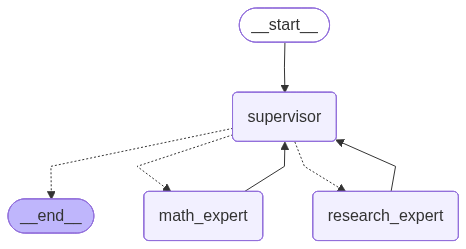

In [11]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
result

{'messages': [HumanMessage(content='what is quantum computing?', additional_kwargs={}, response_metadata={}, id='6efcb9ad-155a-45d1-90a0-986774dc8384'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 101, 'total_tokens': 115, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_899261a2ad', 'id': 'chatcmpl-DOn4pE8ScYF8DvkgM8XUPl6AZTWeU', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, name='supervisor', id='lc_run--019d3a60-79af-7e13-849b-6a4c98962b46-0', tool_calls=[{'name': 'transfer_to_research_expert', 'args': {}, 'id': 'call_YYPMMLg76zslYTIe7T5ErCte', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens

In [13]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is quantum computing?
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_research_expert (call_YYPMMLg76zslYTIe7T5ErCte)
 Call ID: call_YYPMMLg76zslYTIe7T5ErCte
  Args:
================================= Tool Message =================================
Name: transfer_to_research_expert

Successfully transferred to research_expert
================================== Ai Message ==================================
Name: research_expert

Quantum computing is a type of computation that harnesses the collective properties of quantum states, such as superposition, interference, and entanglement, to perform calculations. Unlike classical computers, which use bits as the smallest unit of data (represented as 0s and 1s), quantum computers use quantum bits, or qubits. Qubits can represent and store information in a quantum state that can be bot

In [15]:
# Compile and run
app = workflow.compile()
result = app.invoke({
    "messages": [
        {
            "role": "user",
            "content": "what is the weather in delhi today. Multiply it by 2 and add 5"
        }
    ]
})

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the weather in delhi today. Multiply it by 2 and add 5
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_research_expert (call_dl4v48URM8VCKHMV1cQRh8Y6)
 Call ID: call_dl4v48URM8VCKHMV1cQRh8Y6
  Args:
================================= Tool Message =================================
Name: transfer_to_research_expert

Successfully transferred to research_expert
================================== Ai Message ==================================
Name: research_expert

The current temperature in Delhi is 31°C.
================================== Ai Message ==================================
Name: research_expert

Transferring back to supervisor
Tool Calls:
  transfer_back_to_supervisor (3c995142-6e54-4d2b-a1bb-72ebcf60894e)
 Call ID: 3c995142-6e54-4d2b-a1bb-72ebcf60894e
  Args:
================================= Tool Message ==========

## Similar Modular B2B Agent Workflows Using LangGraph Architecture

---

### 1. Enterprise Knowledge Assistant (Departmental Routing)

**Supervisor Agent**: Routes user queries based on department classification.

| Sub-Agent   | Tool(s)                             | Domain                                  |
| ----------- | ----------------------------------- | --------------------------------------- |
| HR Agent    | RAG over HR policy PDFs             | Employee leave, benefits, reimbursement |
| Legal Agent | DuckDuckGo + legal clause retriever | Contract clauses, compliance summaries  |
| IT Agent    | Internal wiki/status page search    | DevOps runbooks, system troubleshooting |

**Example Workflow**:

* User asks: “How do I apply for medical leave?” → Routed to HR Agent
* User asks: “What’s the termination clause in this NDA?” → Routed to Legal Agent

---

### 2. Procurement Assistant (Currency and Inventory Agents)

**Supervisor Agent**: Routes procurement-related queries to the right agent.

| Sub-Agent      | Tool(s)                    | Function                                   |
| -------------- | -------------------------- | ------------------------------------------ |
| Currency Agent | Exchange rates API         | Converts purchase values across currencies |
| Stock Agent    | Inventory database lookup  | Checks stock availability                  |
| Vendor Agent   | DuckDuckGo (vendor lookup) | Suggests suppliers based on urgency        |

**Example Workflow**:

* “What’s the cost in EUR for 100 widgets?” → Currency Agent
* “Is 50 units of Product X available?” → Stock Agent

---

### 3. Real-Time Financial Assistant (Tax, Investment, Budget)

**Supervisor Agent**: Interprets financial queries and routes accordingly.

| Sub-Agent        | Tool(s)                        | Purpose                          |
| ---------------- | ------------------------------ | -------------------------------- |
| Tax Agent        | Public tax APIs + GPT          | Computes slabs, deductions       |
| Investment Agent | ETF screener or BSE/NSE lookup | Gives investment advice          |
| Budget Agent     | Google Sheets API              | Tracks and analyzes user budgets |

**Example Workflow**:

* “How much tax on ₹10L income?” → Tax Agent
* “Best ETFs to invest in 2025?” → Investment Agent

---

### 4. Customer Support Escalation Bot

**Supervisor Agent**: Classifies user complaints into predefined categories.

| Sub-Agent          | Tool(s)                        | Category            |
| ------------------ | ------------------------------ | ------------------- |
| Billing Agent      | Invoice system + refund APIs   | Handles payments    |
| Tech Support Agent | Internal FAQ or system status  | Troubleshooting     |
| Feedback Agent     | Logging + auto-reply generator | Feedback management |

**Example Workflow**:

* “My payment failed twice.” → Billing Agent
* “App crashes when I log in.” → Tech Support Agent

---

### 5. Data Insights Assistant (Visualization + Summary)

**Supervisor Agent**: Determines whether user needs charts, data, or text insight.

| Sub-Agent       | Tool(s)                 | Role                          |
| --------------- | ----------------------- | ----------------------------- |
| Chart Agent     | Matplotlib/Seaborn      | Generates trend or bar charts |
| SQL Agent       | SQL validated execution | Retrieves data                |
| Narrative Agent | GPT Summary Generator   | Converts numbers to insights  |

**Example Workflow**:

* “Show sales trend for Q1 2024 in Mumbai” → Chart Agent
* “Top-selling SKU last month?” → SQL Agent → Narrative Agent

---

### 6. Travel Planner Bot (End-to-End Itinerary Builder)

**Supervisor Agent**: Breaks down travel requests into sub-tasks.

| Sub-Agent     | Tool(s)         | Task                            |
| ------------- | --------------- | ------------------------------- |
| Flight Agent  | Skyscanner API  | Fetches flight details          |
| Hotel Agent   | Booking.com API | Suggests accommodations         |
| Weather Agent | OpenWeatherMap  | Weather forecasts for locations |

**Example Workflow**:

* “Plan a 3-day trip to Manali with good weather and stay” → All three agents sequenced accordingly

---

### Common Features Across All Use Cases

| Feature                 | Value Proposition                         |
| ----------------------- | ----------------------------------------- |
| LangGraph Routing       | Clean handoff between specialized agents  |
| Tool-Calling Agents     | Real-time system and API integration      |
| Open Source LLMs        | On-premise, low-cost, air-gapped support  |
| Supervisor Agent        | Unified interface, decentralized logic    |
| LangSmith/Graph Tracing | Step-by-step explainability and debugging |

---

## Some more: Advanced B2B Use Cases for LangGraph-Based Multi-Agent Systems

---

### 1. Intelligent Loan Underwriting System

**Industry:** Banking & Financial Services

**Description:**
Automates loan eligibility checks, fraud detection, and escalation for human approval when needed.

**Agents:**

| Agent                  | Responsibility                                  | Tools             |
| ---------------------- | ----------------------------------------------- | ----------------- |
| Document Reader Agent  | Extracts structured data from documents         | PyMuPDF, OCR      |
| Eligibility Evaluator  | Checks applicant details against internal rules | Internal API      |
| Risk Assessor Agent    | Analyzes anomalies or fraud indicators          | Rules Engine, LLM |
| Human Escalation Agent | Notifies human team for high-risk applications  | Email, Slack APIs |

**Supervisor Logic:**
Aggregates results from all agents and routes application for approval, rejection, or manual review.

---

### 2. Intelligent RFP Response Generator

**Industry:** IT Services, Consulting

**Description:**
Generates draft proposals from client RFPs by aligning internal capabilities with client requirements.

**Agents:**

| Agent                  | Responsibility                             | Tools                       |
| ---------------------- | ------------------------------------------ | --------------------------- |
| Scope Extraction Agent | Extracts needs from uploaded RFP PDFs      | LangChain PDF Loader, LLM   |
| Solution Mapping Agent | Aligns RFP scope with service catalog      | RAG over internal solutions |
| Cost Estimator Agent   | Calculates project cost, effort, headcount | Excel API, Financial Model  |
| Compliance Validator   | Ensures compliance with legal norms        | Policy RAG, Regex Validator |

**Output:**
A structured response document with cost, solution, and legal terms ready for client review.

---

### 3. Procurement Intelligence Agent

**Industry:** Manufacturing, Retail

**Description:**
Supports strategic sourcing decisions with vendor intelligence, forecasting, and risk insights.

**Agents:**

| Agent                     | Responsibility                            | Tools                        |
| ------------------------- | ----------------------------------------- | ---------------------------- |
| Vendor Intelligence Agent | Reviews vendor history, pricing, location | Vendor APIs, Web Search      |
| Price Forecasting Agent   | Forecasts pricing trends                  | Time-Series Models (Prophet) |
| Risk Detection Agent      | Detects geopolitical or financial risks   | News API, Country Risk DB    |
| Approval Routing Agent    | Routes final report to approver           | Google Sheets, Email Trigger |

**Supervisor Logic:**
Compiles recommendations and routes through approval chain based on risk and savings potential.

---

### 4. Cross-Departmental Compliance Tracker

**Industry:** Pharma, BFSI, Legal

**Description:**
Monitors departmental adherence to policies like ISO, GDPR, and HIPAA in real time.

**Agents:**

| Agent                    | Responsibility                            | Tools                         |
| ------------------------ | ----------------------------------------- | ----------------------------- |
| Policy Retrieval Agent   | Retrieves and interprets compliance rules | RAG over compliance documents |
| Status Checker Agent     | Checks actual compliance status           | REST APIs to dashboards       |
| Violation Detector Agent | Flags non-compliance or missing evidence  | Rule Engine, Regex            |
| Reporting Agent          | Generates visual reports                  | Matplotlib, Sheets API        |

**Supervisor Logic:**
Aggregates status from all departments and triggers alerts or reports for violations.

---

### 5. AI Executive Assistant for CXOs

**Industry:** Horizontal (All sectors)

**Description:**
Provides real-time business insights to CXOs by consolidating internal and external metrics.

**Agents:**

| Agent                        | Responsibility                          | Tools                         |
| ---------------------------- | --------------------------------------- | ----------------------------- |
| Data Aggregator Agent        | Fetches data from CRMs, ERPs, Sheets    | REST APIs                     |
| Insight Generator Agent      | Summarizes KPIs, trends, and exceptions | LLMs, Data Charts             |
| Risk/Alert Agent             | Highlights urgent issues or anomalies   | Alert Rules Engine            |
| Presentation Generator Agent | Converts insights to PPT or email brief | Markdown to PDF/PPT Generator |

**Supervisor Logic:**
Prioritizes insight generation and formats response as per CXO communication preferences.

---

### 6. Investor Due Diligence Engine

**Industry:** Venture Capital, Private Equity

**Description:**
Automates startup evaluations using financial data, credibility signals, and legal checks.

**Agents:**

| Agent                     | Responsibility                                   | Tools                         |
| ------------------------- | ------------------------------------------------ | ----------------------------- |
| Financial Analyzer Agent  | Reviews startup financials and calculates runway | Excel Loader, Financial Model |
| Founder Credibility Agent | Searches social credibility, media presence      | DuckDuckGo, LinkedIn API      |
| Market Size Estimator     | Calculates TAM/SAM/SOM from external data        | Google Search, LLM            |
| Red Flag Detector         | Detects legal, tax, or fraud issues              | Legal Doc RAG, Regex Filter   |

**Supervisor Logic:**
Compiles scores across all dimensions and flags startups for further diligence or rejection.

---

### 7. Legal Contract Negotiation Assistant

**Industry:** LegalTech, Procurement, SaaS

**Description:**
Reviews third-party contracts, highlights risky clauses, and redlines automatically.

**Agents:**

| Agent                    | Responsibility                  | Tools                      |
| ------------------------ | ------------------------------- | -------------------------- |
| Clause Extractor Agent   | Extracts relevant legal clauses | LangChain PDF Loader, LLM  |
| Deviation Detector Agent | Identifies clause violations    | Company Policy RAG         |
| Redlining Agent          | Suggests modifications          | OpenAI Edit API or DiffLib |
| Negotiation Prep Agent   | Summarizes for negotiation team | Markdown, Email Export     |

**Supervisor Logic:**
Determines which clauses to auto-approve, redline, or escalate for manual review.

---

### LangGraph and LangSmith Advantages Across All Use Cases

| Feature                    | Benefit                                              |
| -------------------------- | ---------------------------------------------------- |
| StateGraph with Conditions | Enables dynamic routing and decision trees           |
| Modular Agent Isolation    | Different tools/LLMs per agent for cost and security |
| Tool Chaining Support      | Combines internal logic with API-based tools         |
| LangSmith Tracing          | Full audit logs and debugging per task               |
| Guardrails & Retries       | Handles edge cases and error resilience              |

---